In [14]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install gymnasium stable-baselines3 numpy pillow scipy matplotlib seaborn

Looking in indexes: https://download.pytorch.org/whl/cu121


# Import Libraries

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from dataclasses import dataclass
from typing import Literal


# Thermal Parameters for Powder Bed Fusion (PBF) Simulation

This code defines a **data class** `ThermalParameters` that stores all the key physical and numerical parameters needed for a **Powder Bed Fusion (PBF)** thermal simulation (commonly used in metal 3D printing / additive manufacturing).

### What is PBF?
Powder Bed Fusion is an additive manufacturing process where a laser or electron beam selectively melts metal powder to build parts layer by layer. Accurate thermal modeling is critical to predict melt pool behavior, temperature distribution, and avoid defects.

### Parameter Meanings & Values

| Parameter                    | Value              | Unit          | Meaning |
|-----------------------------|--------------------|---------------|-------|
| `domain_size_m`             | 1.0e-3 (0.001)    | meter         | Size of the simulation domain (1 mm × 1 mm square) |
| `conductivity`              | 113.0             | W/(m·K)       | Thermal conductivity of the material (typical for some metals like stainless steel or titanium alloys) |
| `volumetric_heat_capacity`  | 2.403e6           | J/(m³·K)      | ρ·Cp — density × specific heat capacity. Controls how fast the material heats up/cools down |
| `melt_threshold`            | 850.0             | Kelvin (K)    | Melting temperature of the material. Above this temperature the material is considered molten |
| `source_power`              | 3.0e6             | Watt          | Laser power (3 MW — very high, typical for focused laser in simulations) |
| `gaussian_width_m`          | 5.0e-6            | meter         | Laser beam radius (standard deviation of the Gaussian heat source). 5 µm is a very focused beam |
| `time_step_s`               | 1.0e-5            | second        | Time step for numerical simulation (10 µs). Controls simulation stability and accuracy |
| `initial_temperature`       | 300.0             | Kelvin (K)    | Starting temperature of the entire domain (room temperature ≈ 27°C) |



In [16]:
# Define a data class to hold all thermal simulation parameters
# Using @dataclass automatically generates __init__, __repr__, etc.
@dataclass
class ThermalParameters:
    """PBF-specific parameters from the manuscript"""

    # Size of the computational domain (square area being simulated)
    # 1.0e-3 m = 1 mm. This is the total width/height of the 2D simulation area.
    domain_size_m: float = 1.0e-3

    # Thermal conductivity of the material
    # How well heat flows through the material (Watts per meter per Kelvin)
    conductivity: float = 113.0

    # Volumetric heat capacity = density × specific heat capacity
    # Determines how much energy is needed to raise the temperature of a unit volume
    # Unit: Joules per cubic meter per Kelvin
    volumetric_heat_capacity: float = 2.403e6

    # Temperature above which the material is considered melted
    # Used to track the melt pool in the simulation
    melt_threshold: float = 850.0

    ##HEAT SOURCE (LASER) PARAMETERS

    # Power of the laser heat source
    # 3.0e6 W = 3 Megawatts (very high power concentrated in a tiny spot)
    source_power: float = 3.0e6

    # Width (standard deviation) of the Gaussian laser beam
    # Smaller value = more focused/stronger peak intensity
    # 5.0e-6 m = 5 micrometers
    gaussian_width_m: float = 5.0e-6

    ##NUMERICAL SIMULATION PARAMETERS

    # Time step for the numerical solver (explicit time marching)
    # 1.0e-5 s = 10 microseconds. Small time step needed for stability with high power laser
    time_step_s: float = 1.0e-5

    # Initial temperature of the entire powder bed before laser starts
    # 300 K ≈ 27°C (room temperature)
    initial_temperature: float = 300.0

# Modified PBF Toolpath Environment (RL Gym Env)

This notebook cell defines **`PBFToolpathEnv`** — a custom **OpenAI Gym** environment for training Reinforcement Learning agents to optimize **laser toolpaths** in **Powder Bed Fusion (PBF)** additive manufacturing.

### Key Improvements in this Version
- **Enhanced Action Space**: 6 discrete actions (4 movements + laser toggle + power control)
- **Realistic Thermal Dynamics**: Temperature and phase (melted/solid) tracking
- **Better Reward Shaping**: Balances coverage, spill-over penalty, and energy efficiency
- **Multi-channel Observation**: Mask, position (implicit), temperature, phase, and power level

### Action Space (Discrete 6)
| Action | Description |
|--------|-----------|
| 0      | Move Up |
| 1      | Move Down |
| 2      | Move Left |
| 3      | Move Right |
| 4      | Toggle Laser On/Off |
| 5      | Increase Laser Power Level (only when laser is on) |

### Observation Space
Shape: `(5, n, n)` — 5 channels of `n × n` grid:
- Channel 0: **Mask** (print area = 1, outside = 0)
- Channel 1: **Unused/Zero** Currently all zeros (reserved for future use, e.g., position encoding or velocity)
- Channel 2: **Normalized Temperature**
- Channel 3: **Phase** (1 = melted, 0 = unmelted)
- Channel 4: **Power Level Map** (current power broadcasted)

### Main Parameters (from `ThermalParameters`)
- Uses `ThermalParameters()` for physical constants (melting point, etc.)
- Laser power levels: 0 (off) → 3 (high)



In [17]:
class PBFToolpathEnv(gym.Env):
    """
    Modified PBF Toolpath Environment for better realism.
    Changes:
    - Action space now includes laser power control
    - Improved thermal dynamics
    - Better reward shaping
    """

    def __init__(self, n=10, split: Literal["train", "validation", "test"] = "train", seed=None):
        """
        Initialize the environment.

        Args:
            n (int): Grid size (n x n). Default = 10 for fast training.
            split: Dataset split (not heavily used yet, for future extension).
            seed: Random seed for reproducibility.
        """
        super().__init__()                    # Initialize parent Gym environment
        self.n = n                            # Grid resolution (width and height)
        self.split = split                    # Train/val/test flag
        self.rng = np.random.default_rng(seed)  # Random number generator

        # ACTION SPACE
        # 6 discrete actions:
        # 0-3: Movement, 4: Toggle laser, 5: Increase power
        self.action_space = spaces.Discrete(6)

        # OBSERVATION SPACE
        # 5 channels: Mask, Temperature, Phase, Power Level + one unused (for position info)
        # Values normalized between 0 and 1
        self.observation_space = spaces.Box(
            low=0,
            high=1,
            shape=(5, n, n),
            dtype=np.float32
        )

        # Load physical parameters from previous dataclass
        self.params = ThermalParameters()

        # Laser power control (new feature)
        self.power_level = 0
        self.max_power_level = 3          # Levels: 0=off, 1=low, 2=med, 3=high

        # Reset environment to initial state
        self.reset()

    def reset(self, seed=None):
        """Reset environment to starting state"""
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        # Create a simple square printable area (mask)
        # Border of 2 cells left empty for testing
        self.mask = np.zeros((self.n, self.n), dtype=np.float32)
        self.mask[2:-2, 2:-2] = 1.0

        # Start laser at center of grid
        self.current_pos = [self.n//2, self.n//2]

        # Laser starts OFF
        self.laser_on = False
        self.power_level = 0

        # Phase grid: 0 = unmelted, 1 = melted
        self.phase = np.zeros((self.n, self.n), dtype=np.float32)

        # Temperature grid: start at room temperature
        self.temperature = np.ones((self.n, self.n), dtype=np.float32) * self.params.initial_temperature

        return self._get_obs(), {}

    def step(self, action):
        """
        Take one step in the environment.
        Returns: observation, reward, terminated, truncated, info
        """
        reward = 0.0

        # Process action
        if action < 4:                    # 0-3: Movement actions
            self._move(action)
        elif action == 4:                 # 4: Toggle laser on/off
            self.laser_on = not self.laser_on
            if not self.laser_on:
                self.power_level = 0      # Reset power when turning off
        elif action == 5:                 # 5: Increase power level
            if self.laser_on:
                self.power_level = min(self.max_power_level, self.power_level + 1)

        # Apply heat only when laser is on and has power
        if self.laser_on and self.power_level > 0:
            self._apply_thermal_step()
            # Small penalty for using higher power (encourages efficiency)
            reward -= 0.05 * self.power_level

        # Calculate main reward based on coverage and penalties
        reward += self._compute_reward()

        terminated = self._is_done()      # Episode ends when printing is complete

        return self._get_obs(), reward, terminated, False, {
            "coverage": self.phase.mean(),      # Fraction of area melted
            "power_level": self.power_level
        }

    def _move(self, action):
        """Move the laser head in one of four directions"""
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # Up, Down, Left, Right
        dx, dy = directions[action]
        # Update position with boundary clipping
        self.current_pos[0] = np.clip(self.current_pos[0] + dx, 0, self.n-1)
        self.current_pos[1] = np.clip(self.current_pos[1] + dy, 0, self.n-1)

    def _apply_thermal_step(self):
        """Simplified but improved thermal simulation at current position"""
        x, y = self.current_pos
        # Heat input scales with power level
        heat_input = 80 * (self.power_level + 1)
        # Apply heat and cap maximum temperature
        self.temperature[x, y] = min(2200, self.temperature[x, y] + heat_input)

        # Update phase (melted material)
        if self.temperature[x, y] > self.params.melt_threshold:
            self.phase[x, y] = 1.0

    def _compute_reward(self):
        """Reward function: encourage filling mask while penalizing overflow and time"""
        # Reward for correctly melting inside the mask
        fill_reward = 10.0 * np.sum(self.phase * self.mask)
        # Penalty for melting outside the desired area
        spill_penalty = -1 * np.sum(self.phase * (1 - self.mask))
        # Small penalty per step (encourages efficiency)
        step_penalty = -0.1
        efficiency = -0.02 * self.power_level
        return fill_reward + spill_penalty + step_penalty + efficiency

    def _get_obs(self):
       """Construct the 5-channel observation tensor with position encoding"""
       obs = np.zeros((5, self.n, self.n), dtype=np.float32)

       obs[0] = self.mask                    # Channel 0: Print mask
       obs[1] = self._get_position_encoding() # Channel 1: Position of the laser (Gaussian)
       obs[2] = self.temperature / 2200.0    # Channel 2: Normalized Temperature
       obs[3] = self.phase                   # Channel 3: Melted phase

    # Channel 4: Current power level
       power_map = np.full((self.n, self.n),
                       self.power_level / self.max_power_level,
                       dtype=np.float32)
       obs[4] = power_map

       return obs



    def _get_position_encoding(self):
       """Create a position encoding channel - Gaussian blob at current position"""
       pos_encoding = np.zeros((self.n, self.n), dtype=np.float32)
       x, y = self.current_pos

       # Gaussian (Recommended - smoother gradient for CNN)
       xx, yy = np.meshgrid(np.arange(self.n), np.arange(self.n))
       distance = ((xx - x) ** 2 + (yy - y) ** 2)
       pos_encoding = np.exp(-distance / (2 * 1.5**2))  # sigma = 1.5

       return pos_encoding

    def _is_done(self):
        """Episode ends when entire mask is successfully melted"""
        return np.all(self.phase >= self.mask - 0.01)


# Testing the environment
env = PBFToolpathEnv(n=10, split="test")
print("✅ Modified Environment Created Successfully!")
print("New Action Space Size:", env.action_space.n)

✅ Modified Environment Created Successfully!
New Action Space Size: 6


# Custom CNN Feature Extractor + PPO Training for PBF Toolpath

This cell defines a **custom Convolutional Neural Network (CNN)** feature extractor tailored for the `PBFToolpathEnv` and trains a **PPO (Proximal Policy Optimization)** agent using **Stable-Baselines3**.

### Why a Custom CNN?
- The observation is a **5-channel 10×10 grid** (Mask, Temperature, Phase, Power, etc.)
- Standard CNNs in SB3 work well, but a custom one gives better control over architecture for small grids.
- This extractor processes spatial patterns (laser position, melted areas, temperature distribution) effectively.

### Model Architecture Summary
- Input: `(5, 10, 10)` → 5 channels, 10×10 grid
- Conv2d (16 filters) → ReLU → MaxPool (→ 5×5)
- Conv2d (32 filters) → ReLU → MaxPool (→ 2×2)
- Flatten → Linear (to 64 features) → ReLU
- These 64 features are then passed to the PPO policy (actor & critic heads)

### Training Setup
- Vectorized environment (4 parallel environments for faster training)
- PPO algorithm with tuned hyperparameters
- Total training: 50,000 timesteps



In [18]:
import torch as th
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class CustomCNN(BaseFeaturesExtractor):
    """
    Custom CNN feature extractor for the PBF environment.
    Input size (5, 10, 10)
    """

    def __init__(self, observation_space: gym.spaces.Box, features_dim: int = 64):
        """
        Initialize the CNN feature extractor.

        Args:
            observation_space: The observation space from the Gym environment
            features_dim: Output feature dimension (fed to policy)
        """
        # Call parent constructor (required by Stable-Baselines3)
        super().__init__(observation_space, features_dim)

        # Number of input channels = 5 (Mask, Temp, Phase, Power, etc.)
        n_input_channels = observation_space.shape[0]

        # Define the convolutional backbone
        self.cnn = nn.Sequential(
            # First convolutional layer
            # Input: 5 channels → Output: 16 channels, 10x10 spatial size
            nn.Conv2d(n_input_channels, 16, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),                                      # Activation
            nn.MaxPool2d(kernel_size=2, stride=2),          # Downsample to 5x5

            # Second convolutional layer
            # Input: 16 channels → Output: 32 channels, 5x5
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),          # Downsample to 2x2 (approx)

            nn.Flatten(),                                   # Flatten to 1D vector
        )

        # Compute the exact flattened size by doing a dry run with a sample observation
        with th.no_grad():
            # Create a dummy observation from the space and add batch dimension
            sample_obs = observation_space.sample()[None]   # Shape: (1, 5, 10, 10)
            n_flatten = self.cnn(th.as_tensor(sample_obs).float()).shape[1]

        # Final linear layer to produce desired feature dimension
        self.linear = nn.Sequential(
            nn.Linear(n_flatten, features_dim),
            nn.ReLU()
        )

    def forward(self, observations: th.Tensor) -> th.Tensor:
        """
        Forward pass: extract features from observations.
        """
        # Pass through CNN → Flatten → Linear layer
        cnn_features = self.cnn(observations)
        return self.linear(cnn_features)


# CREATE VECTORIZED ENVIRONMENT
# Create 4 parallel environments for faster and more stable training
vec_env = make_vec_env(
    lambda: PBFToolpathEnv(n=10, split="train"),
    n_envs=4
)

# CREATE AND TRAIN PPO MODEL
model = PPO(
    "CnnPolicy",                          # Use CNN policy (actor-critic)
    vec_env,                              # Vectorized environment
    verbose=1,                            # Print training progress
    learning_rate=5e-4,                   # Learning rate
    gamma=0.99,                           # Discount factor (long-term reward)
    n_steps=1024,                         # Number of steps per update
    policy_kwargs=dict(                   # Custom policy settings
        features_extractor_class=CustomCNN,           # Use our custom CNN
        features_extractor_kwargs=dict(features_dim=64),  # Output 64 features
        normalize_images=False                        # Do not normalize (already in [0,1])
    )
)

# Start training
model.learn(total_timesteps=50000)        # Train for 50,000 environment steps

# Save the trained model
model.save("ppo_pbf_modified")

print("✅ Training Completed with Modified Action Space and Custom CNN!")

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 1385 |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 4096 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 419          |
|    iterations           | 2            |
|    time_elapsed         | 19           |
|    total_timesteps      | 8192         |
| train/                  |              |
|    approx_kl            | 0.0055229748 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.79        |
|    explained_variance   | -0.000272    |
|    learning_rate        | 0.0005       |
|    loss                 | 1.69e+06     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.000835    |
|    value_loss           | 3.27e+06     |
------------------------------------------

# Visualization & Evaluation of Trained PBF Agent

This cell contains:
- A clean plotting function `plot_episode()` to visualize the agent's performance
- A test loop that runs the trained PPO agent on the environment
- Displays key metrics (Coverage & Final Power Level)

### What the Plots Show

| Plot | Meaning |
|------|--------|
| **Target Mask** | The desired area that should be melted (white = printable region) |
| **Temperature Field** | Current temperature distribution (hot = bright yellow/white) |
| **Melted Phase** | Areas successfully melted by the agent (white = melted) |

### Purpose
- Quickly evaluate how well the trained agent performs
- Visually inspect toolpath quality, melt coverage, and temperature distribution
- Useful for debugging



In [19]:
def plot_episode(env, title="PBF Toolpath Result"):
    """
    Improved plotting function for Google Colab.
    Visualizes the target mask, temperature field, and final melted phase.

    Args:
        env: The PBFToolpathEnv instance after running an episode
        title: Title for the overall figure
    """
    # Create a figure with 3 subplots side by side
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    # Plot 1: Target Mask
    # Shows the desired printing area (what the agent should melt)
    axs[0].imshow(env.mask, cmap='gray')
    axs[0].set_title('Target Mask')
    axs[0].axis('off')                    # Hide axes for clean look

    # Plot 2: Temperature Field
    # Shows current temperature distribution using 'hot' colormap
    im1 = axs[1].imshow(env.temperature, cmap='hot')
    axs[1].set_title('Temperature Field')
    axs[1].axis('off')
    # Add colorbar to show temperature scale
    fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

    # Plot 3: Melted Phase
    # Shows which areas have been successfully melted
    axs[2].imshow(env.phase, cmap='gray')
    axs[2].set_title('Melted Phase')
    axs[2].axis('off')

    # Add main title and adjust layout
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


Coverage achieved: 0.0
Final Power Level: 0


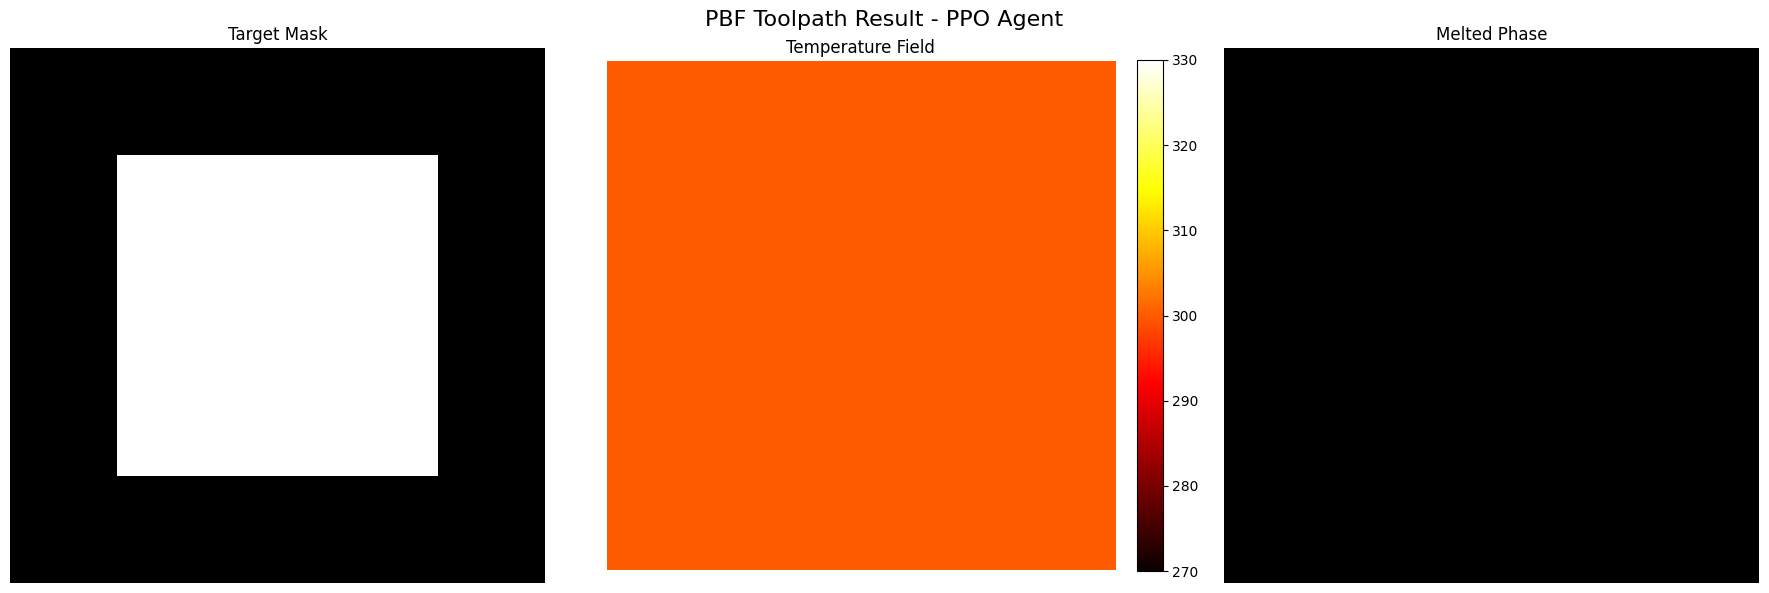

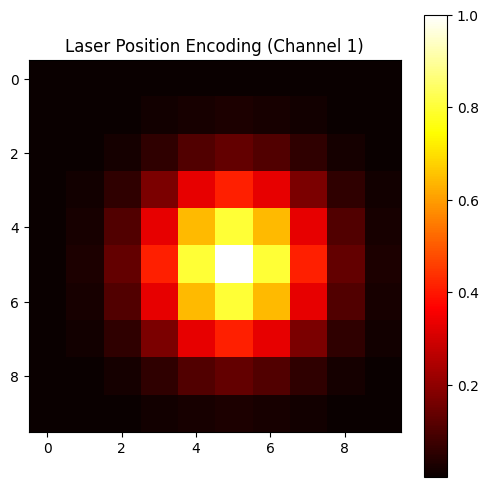

In [20]:
# Reset environment with a fixed seed for reproducible results
obs, _ = env.reset(seed=42)

# Run the trained agent
max_steps = 300
for step in range(max_steps):
    action, _ = model.predict(obs, deterministic=True)  # Use trained model
    obs, reward, done, _, info = env.step(action)

    if done:
        print(f"Episode finished successfully in {step+1} steps!")
        break

print("Coverage achieved:", info.get("coverage", 0))
print("Final Power Level:", info.get("power_level", 0))

# Call the plotting function
plot_episode(env, title="PBF Toolpath Result - PPO Agent")


def plot_position(env):
    plt.figure(figsize=(6,6))
    pos_map = env._get_position_encoding()
    plt.imshow(pos_map, cmap='hot')
    plt.title('Laser Position Encoding (Channel 1)')
    plt.colorbar()
    plt.show()

plot_position(env)   #verify position channel is working



# DQN Training Setup for PBF Toolpath Environment

This cell sets up and configures a **DQN (Deep Q-Network)** agent for the Powder Bed Fusion toolpath optimization task.

### DQN vs PPO
- **DQN** is value-based (learns Q-values) and works well with discrete action spaces.
- Uses a **replay buffer** for stable off-policy learning.
- Often requires careful tuning of exploration parameters.

### Key Features in this Setup
- Uses the same **CustomCNN** feature extractor as the PPO version (5-channel input)
- Vectorized environment (4 parallel envs) for faster data collection
- Standard DQN hyperparameters tuned for this environment
- Proper exploration schedule (starts high, decays to low)

### Main Hyperparameters Explained
- `learning_rate=1e-4`: Smaller than PPO (DQN is more sensitive)
- `buffer_size=50000`: Experience replay buffer size
- `exploration_final_eps=0.05`: Final random action probability
- `target_update_interval`: How often to update the target network

In [21]:
# Import DQN algorithm and evaluation callback from Stable-Baselines3
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import EvalCallback

# CREATE VECTORIZED ENVIRONMENT
# Create multiple parallel environments for faster training
vec_env = make_vec_env(
    lambda: PBFToolpathEnv(n=10, split="train"),   # Use training split
    n_envs=4                                       # 4 parallel environments
)

# CREATE DQN MODEL
model = DQN(
    "CnnPolicy",                          # Use CNN policy (pairs with CustomCNN)
    vec_env,                              # Vectorized environment

    verbose=1,                            # Print training logs
    learning_rate=1e-4,                   # Learning rate (smaller for DQN stability)

    # REPLAY BUFFER SETTINGS
    buffer_size=50000,                    # Size of experience replay buffer
    learning_starts=1000,                 # Collect some experiences before starting training

    batch_size=32,                        # Number of samples per training update
    gamma=0.99,                           # Discount factor for future rewards

    # TRAINING FREQUENCY
    train_freq=4,                         # Train every 4 environment steps
    target_update_interval=1000,          # Update target network every 1000 steps

    # EXPLORATION SETTINGS
    exploration_final_eps=0.05,           # Final epsilon (random action probability)
    exploration_fraction=0.2,             # Fraction of total timesteps for epsilon decay

    # POLICY NETWORK SETTINGS
    policy_kwargs=dict(
        features_extractor_class=CustomCNN,                    # Use our custom CNN extractor
        features_extractor_kwargs=dict(features_dim=64),       # Output feature size
        normalize_images=False                                 # Images already normalized
    )
)

print("DQN Model Ready for Training")

Using cpu device
DQN Model Ready for Training


# Training the DQN Agent

This cell starts the actual **training** of the DQN model on the PBF Toolpath Environment.

### What This Cell Does:
- Runs the DQN training loop for **80,000 timesteps**
- Logs progress every 10 training updates
- Saves the final trained model

### Training Notes:
- 80,000 timesteps is a reasonable starting point for this small 10×10 grid environment.
- Training time depends on your Colab runtime (GPU recommended for faster training).
- The model learns to balance movement, laser toggling, and power control to maximize coverage while minimizing energy waste.



In [22]:
print("Starting DQN Training....")

# TRAINING
model.learn(
    total_timesteps=80000,      # Total number of environment steps to train for
                                # 80,000 steps is a good starting point for this env
    log_interval=10             # Log training progress (average reward, etc.)
                                # every 10 updates to keep output clean
)

# SAVE THE TRAINED MODEL
# Save model so you can reload it later without retraining
model.save("dqn_pbf_toolpath")

# Confirm training finished successfully
print("DQN Training Completed!")

Starting DQN Training....
DQN Training Completed!


# Test & Evaluate the Trained DQN Agent

This cell evaluates the trained **DQN model** on a fresh test environment.

### What This Cell Does:
- Creates a new test environment with fixed seed (`seed=42`) for reproducible results
- Runs the trained DQN agent using **deterministic** (greedy) predictions
- Tracks total reward, number of steps, and final coverage
- Visualizes the final result using the `plot_episode()` function

### Key Metrics:
- **Steps**: How many actions the agent took to complete the task
- **Coverage**: Fraction of the target mask successfully melted (closer to 1.0 is better)
- **Total Reward**: Overall score based on the environment’s reward function


Test Completed in 200 steps
Coverage: 0.000
Total Reward: -20.00


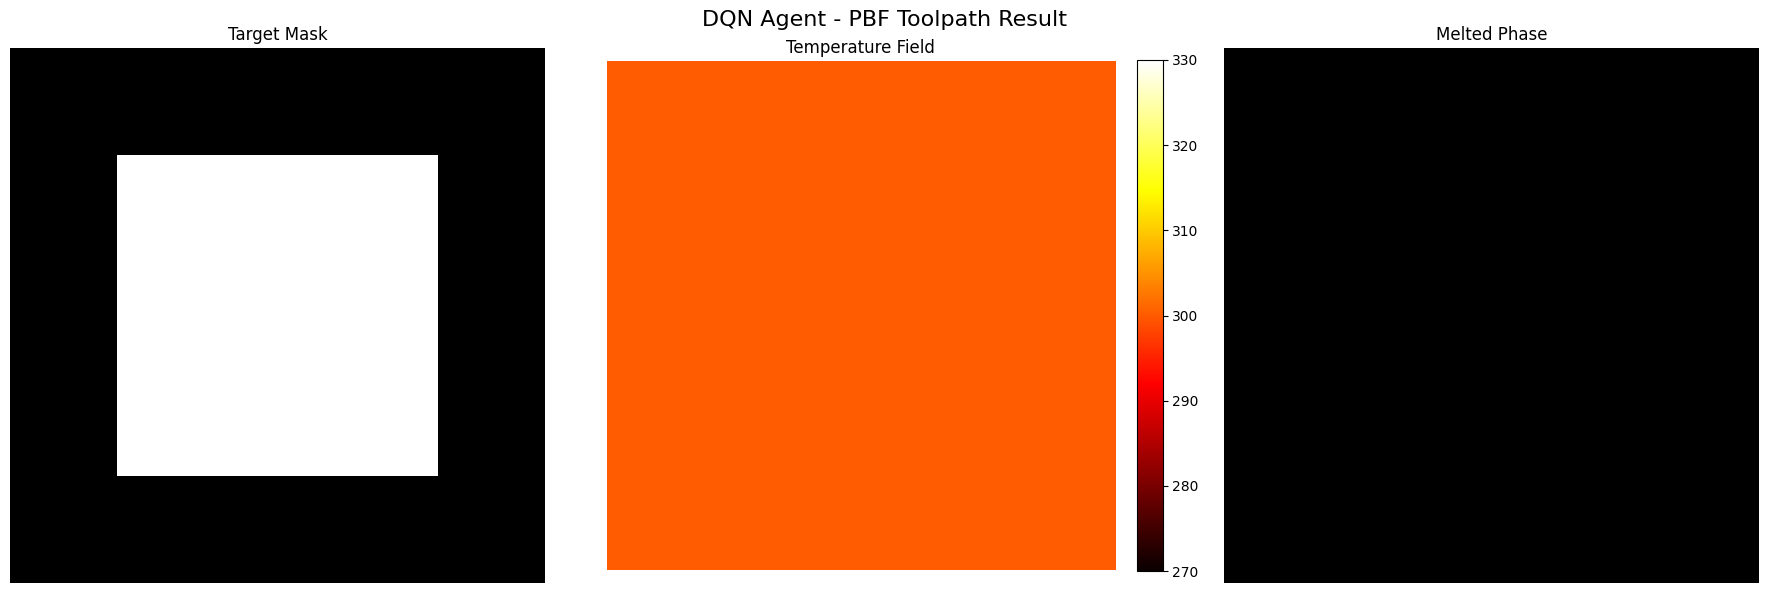

In [23]:
# Using fixed seed=42
test_env = PBFToolpathEnv(n=10, split="test", seed=42)

# Reset the test environment to get initial observation
obs, _ = test_env.reset()

# Initialize tracking variables
total_reward = 0.0
steps = 0

# RUN AGENT EVALUATION
# Run the agent for a maximum of 200 steps
for _ in range(200):   # Max 200 steps (safety limit)
    # Get action from trained DQN model (deterministic = best action, no exploration)
    action, _ = model.predict(obs, deterministic=True)

    # Take the action in the environment
    obs, reward, done, _, info = test_env.step(action)

    # Accumulate reward and count steps
    total_reward += reward
    steps += 1

    # Stop early if the episode is completed (full coverage achieved)
    if done:
        break

# EVALUATION RESULTS
print(f"Test Completed in {steps} steps")
print(f"Coverage: {info.get('coverage', 0):.3f}")   # Coverage percentage (0.0 to 1.0)
print(f"Total Reward: {total_reward:.2f}")

# VISUALIZE FINAL RESULT
# Use the plotting function defined earlier to show results
plot_episode(test_env, title="DQN Agent - PBF Toolpath Result")

# DQN vs PPO Agent Comparison

This cell performs a **head-to-head comparison** between the trained **DQN** and **PPO** agents on the PBF Toolpath Environment.

### What This Cell Does:
- Tests both DQN and PPO agents on separate test environments
- Runs each agent until completion or max steps
- Prints detailed metrics (Steps, Coverage, Total Reward)
- Visualizes both agents’ final results
- Displays a clean comparison table

### Evaluation Results (from the plot):

- **Left (Target Mask)**: Black background with a **white square** in the center. This is the desired area the agent must melt.
- **Middle (Temperature Field)**: Uniform orange color across the entire grid. The colorbar shows temperatures ranging from ~270K (dark red) to 330K (bright yellow). This suggests the laser heated the whole area uniformly but not very effectively.
- **Right (Melted Phase)**: Completely black (no white areas). This means the agent **failed to melt** any significant portion of the target mask.

The PPO agent in that particular run did not achieve good coverage — likely due to insufficient training, poor policy, or the laser not being turned on properly.




Starting DQN vs PPO Comparison...

Testing DQN Agent...
DQN  → Steps: 300 | Coverage: 0.000 | Reward: -30.00


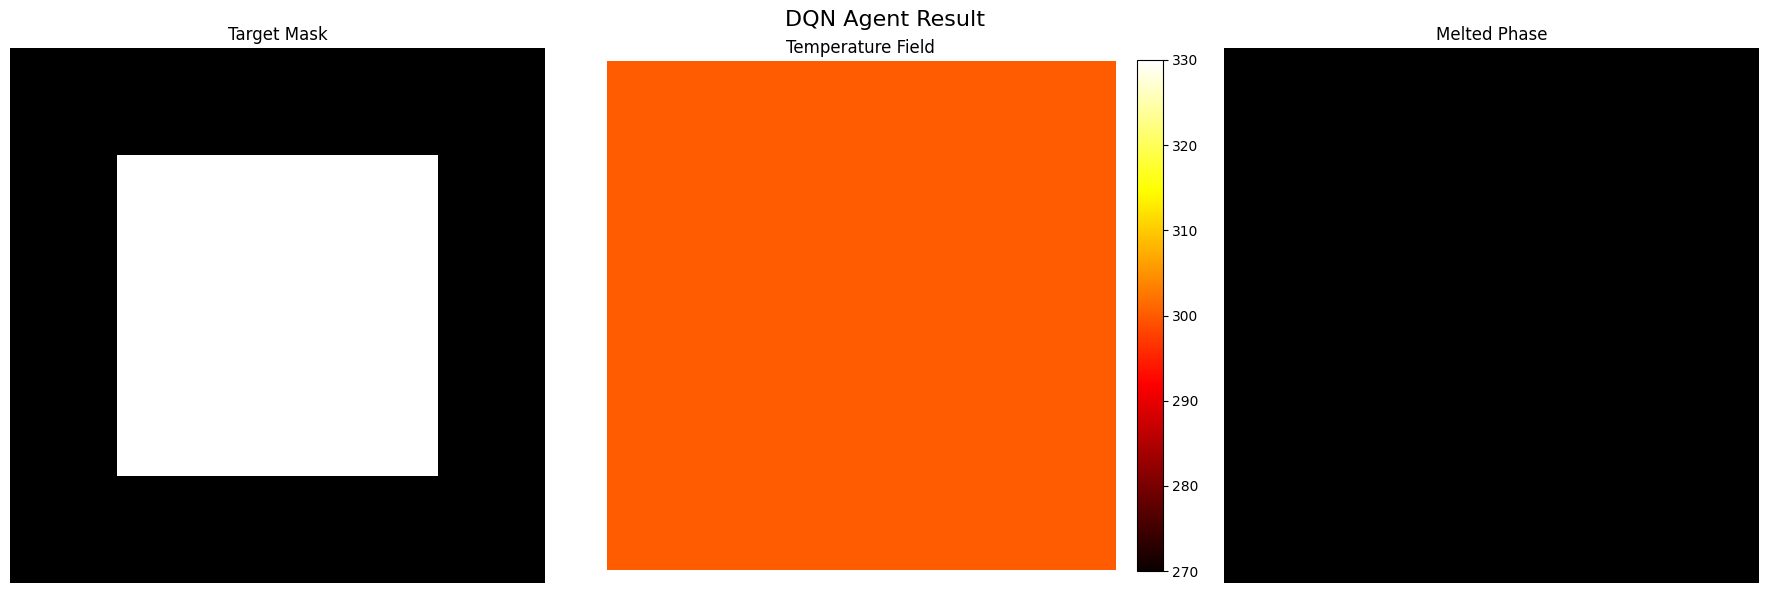


Testing PPO Agent...
Loaded saved PPO model
PPO  → Steps: 300 | Coverage: 0.000 | Reward: -30.00


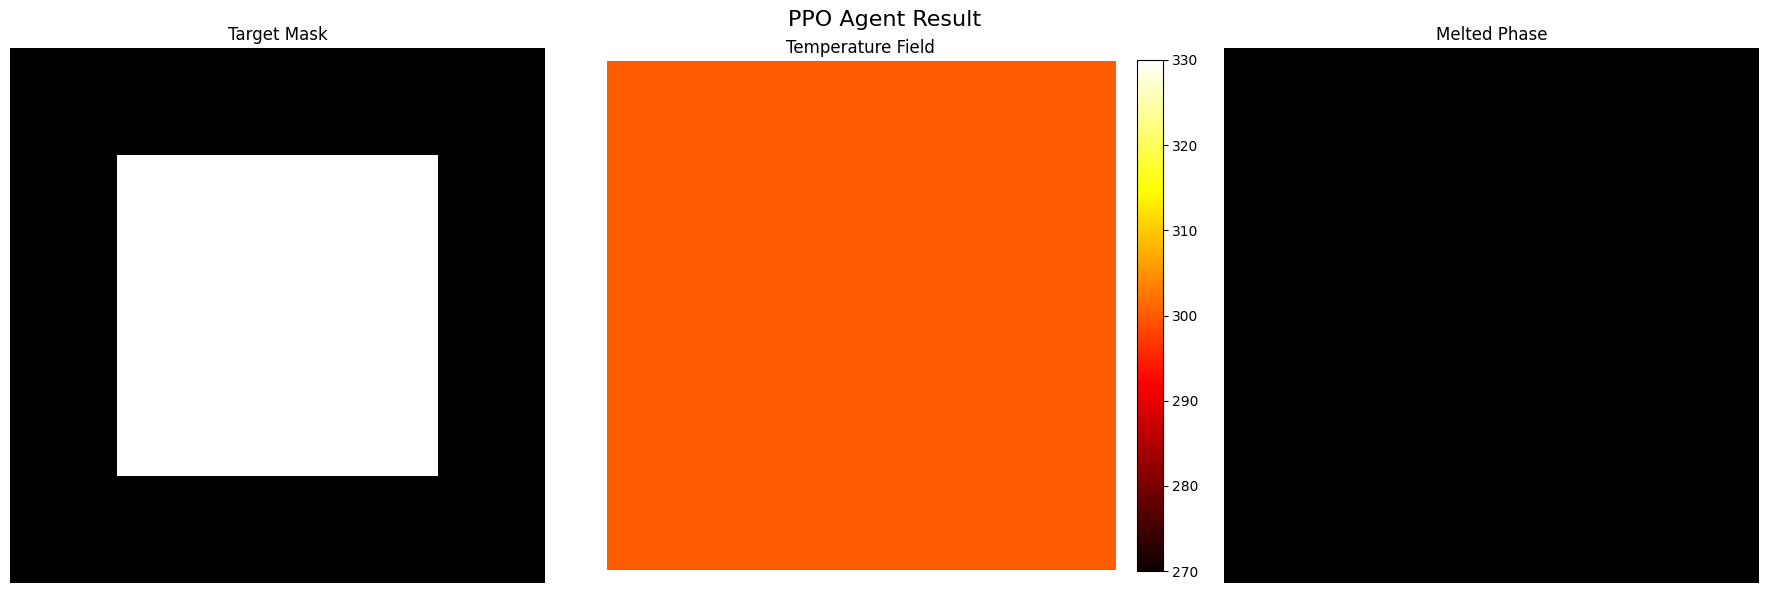


FINAL COMPARISON TABLE
Metric       DQN          PPO         
------------------------------------------------------------
Steps        300          300         
Coverage     0.000        0.000       
Total Reward -30.00       -30.00      


In [24]:
print("Starting DQN vs PPO Comparison...\n")

# Test DQN
print("Testing DQN Agent...")
dqn_env = PBFToolpathEnv(n=10, split="test", seed=42)
obs, _ = dqn_env.reset()
dqn_steps = 0
dqn_reward = 0.0

for _ in range(300):
    action, _ = model.predict(obs, deterministic=True)   # model = DQN
    obs, reward, done, _, info = dqn_env.step(action)
    dqn_reward += reward
    dqn_steps += 1
    if done:
        break

dqn_coverage = info.get("coverage", 0)
print(f"DQN  → Steps: {dqn_steps:3d} | Coverage: {dqn_coverage:.3f} | Reward: {dqn_reward:.2f}")

plot_episode(dqn_env, title="DQN Agent Result")

# Test PPO
print("\nTesting PPO Agent...")

try:
    ppo_model = PPO.load("ppo_pbf_modified")   # or "ppo_pbf_custom_cnn"
    print("Loaded saved PPO model")
except:
    print("PPO model not found. Training a quick one...")
    quick_env = make_vec_env(lambda: PBFToolpathEnv(n=10, split="train"), n_envs=2)
    ppo_model = PPO("CnnPolicy", quick_env, verbose=0, learning_rate=5e-4)
    ppo_model.learn(total_timesteps=40000)
    ppo_model.save("ppo_pbf_modified")

# Run PPO
ppo_env = PBFToolpathEnv(n=10, split="test", seed=43)
obs, _ = ppo_env.reset()
ppo_steps = 0
ppo_reward = 0.0

for _ in range(300):
    action, _ = ppo_model.predict(obs, deterministic=True)
    obs, reward, done, _, info = ppo_env.step(action)
    ppo_reward += reward
    ppo_steps += 1
    if done:
        break

ppo_coverage = info.get("coverage", 0)
print(f"PPO  → Steps: {ppo_steps:3d} | Coverage: {ppo_coverage:.3f} | Reward: {ppo_reward:.2f}")

plot_episode(ppo_env, title="PPO Agent Result")

# --- Summary Table ---
print("\n" + "="*60)
print("FINAL COMPARISON TABLE")
print("="*60)
print(f"{'Metric':<12} {'DQN':<12} {'PPO':<12}")
print("-"*60)
print(f"{'Steps':<12} {dqn_steps:<12} {ppo_steps:<12}")
print(f"{'Coverage':<12} {dqn_coverage:<12.3f} {ppo_coverage:<12.3f}")
print(f"{'Total Reward':<12} {dqn_reward:<12.2f} {ppo_reward:<12.2f}")
print("="*60)